# ASL Lingo Report / Analysis

This notebook loads the SignSense dataset, splits it into train/validation/test, and evaluates the trained CNN model (confusion matrix, per-class metrics, accuracy).

In [11]:
# Imports: PyTorch, torchvision, sklearn (metrics), and local model definition
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

from model import ASLCNN, IMG_SIZE

## 1. Paths and transforms

Set data root (SignSense folder), train directory, and model checkpoint path. Use the same image size and eval transforms as training (resize + ToTensor, no augmentation).

In [12]:
data_root = Path("SignSense")
train_dir = data_root / "asl_alphabet_train"  # Expects A/, B/, ..., Z/ subfolders
model_path = "model.pt"

# Eval: resize to IMG_SIZE (must match model) and ToTensor only
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

print("IMG_SIZE =", IMG_SIZE)
print("Train dir exists:", train_dir.exists())
print("Model exists:", Path(model_path).exists())

IMG_SIZE = 180
Train dir exists: True
Model exists: True


## 2. Load dataset and split (80% train, 10% val, 10% test)

Use `ImageFolder` on the train directory, then `random_split` with a fixed seed so the split is reproducible. Build separate Subsets with eval transforms for train/val/test.

In [13]:
full_dataset = datasets.ImageFolder(root=str(train_dir))
n = len(full_dataset)

train_size = int(0.8 * n)
test_size = int(0.1 * n)
val_size = n - train_size - test_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=str(train_dir), transform=eval_transforms),
    train_subset.indices,
)
validation_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=str(train_dir), transform=eval_transforms),
    val_subset.indices,
)
test_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=str(train_dir), transform=eval_transforms),
    test_subset.indices,
)

print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))
print("Classes:", full_dataset.classes)

Train: 164909
Validation: 20615
Test: 20613
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


Summary table: number of images in each split.

In [14]:
split_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Count": [len(train_dataset), len(validation_dataset), len(test_dataset)]
})

split_df

,Split,Count
0,Train,164909
1,Validation,20615
2,Test,20613


Per-class image counts (from full dataset). We use this to check balance and for the class distribution plot.

In [15]:
classes = full_dataset.classes

labels_all = [label for _, label in full_dataset.samples]
class_counts = pd.Series(labels_all).value_counts().sort_index()

class_df = pd.DataFrame({
    "Class Index": range(len(classes)),
    "Letter": classes,
    "Image Count": class_counts.values
})

class_df

,Class Index,Letter,Image Count
0,0,A,8458
1,1,B,8309
2,2,C,8146
3,3,D,7629
4,4,E,7744
5,5,F,8031
6,6,G,7844
7,7,H,7906
8,8,I,7953
9,9,J,7503


Bar chart of class distribution across the 26 letters.

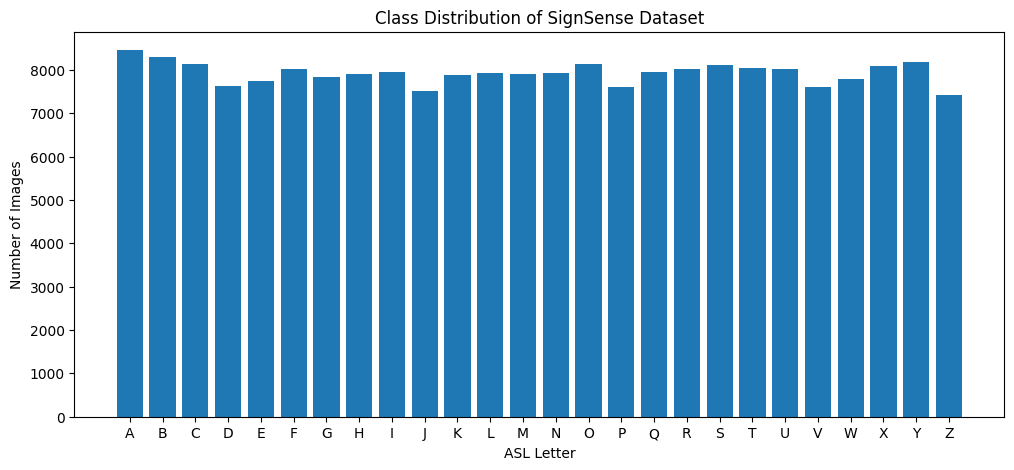

In [16]:
plt.figure(figsize=(12, 5))
plt.bar(class_df["Letter"], class_df["Image Count"])
plt.xlabel("ASL Letter")
plt.ylabel("Number of Images")
plt.title("Class Distribution of SignSense Dataset")
plt.show()

## 3. Load trained model

Load the checkpoint (`model.pt`), instantiate `ASLCNN` with the same number of classes, and load `state_dict`. Run on MPS/CUDA if available.

In [17]:
device = torch.device(
    "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

# Load checkpoint: state_dict, classes, img_size
checkpoint = torch.load(model_path, map_location=device)
classes = checkpoint["classes"]

model = ASLCNN(num_classes=len(classes)).to(device)
model.load_state_dict(checkpoint["state_dict"])
model.eval()

print("Loaded model on:", device)
print("Classes:", classes)
print("Checkpoint img_size:", checkpoint.get("img_size"))

Loaded model on: mps
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Checkpoint img_size: 180


Create DataLoaders for validation and test sets (no shuffle, batch size 64).

In [18]:
validation_loader = DataLoader(validation_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Helper: run the model on a loader and return accuracy plus all predictions and labels (for confusion matrix and classification report).

In [19]:
def evaluate_model(model, loader, device):
    """Run model on loader; return accuracy and arrays of labels/predictions for metrics."""
    all_preds = []
    all_labels = []
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)  # Predicted class index per sample

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100.0 * correct / total
    return acc, np.array(all_labels), np.array(all_preds)

## 4. Validation and test accuracy

Run evaluation on both validation and test loaders; display accuracies in a table.

In [20]:
# Get accuracy and collect all preds/labels for later metrics
val_acc, val_labels, val_preds = evaluate_model(model, validation_loader, device)
test_acc, test_labels, test_preds = evaluate_model(model, test_loader, device)

acc_df = pd.DataFrame({
    "Split": ["Validation", "Test"],
    "Accuracy (%)": [val_acc, test_acc]
})

acc_df

,Split,Accuracy (%)
0,Validation,97.724958
1,Test,97.346335


## 5. Classification report (test set)

Per-class precision, recall, F1, and support on the test set.

In [21]:
report = classification_report(
    test_labels,
    test_preds,
    target_names=classes,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
A,0.977081,0.960854,0.968900,843.000000
B,0.976303,0.976303,0.976303,844.000000
C,0.997468,0.985000,0.991195,800.000000
D,0.982313,0.962667,0.972391,750.000000
E,0.969582,0.973282,0.971429,786.000000
F,0.993789,0.981595,0.987654,815.000000
G,0.991315,0.979167,0.985203,816.000000
H,0.971798,0.993990,0.982769,832.000000
I,0.967541,0.977301,0.972396,793.000000
J,0.983936,0.989233,0.986577,743.000000


## 6. Confusion matrix

Rows = true class, columns = predicted class. Diagonal = correct; off-diagonal = confusions (e.g. M predicted as N).

In [22]:
def evaluate_top3(model, loader, device):
    top1_correct = 0
    top3_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            top3 = torch.topk(outputs, 3, dim=1).indices

            top1_preds = top3[:, 0]
            top1_correct += (top1_preds == labels).sum().item()

            for i in range(labels.size(0)):
                if labels[i].item() in top3[i].tolist():
                    top3_correct += 1

            total += labels.size(0)

    top1_acc = 100.0 * top1_correct / total
    top3_acc = 100.0 * top3_correct / total
    return top1_acc, top3_acc

In [23]:
top1_acc, top3_acc = evaluate_top3(model, test_loader, device)

topk_df = pd.DataFrame({
    "Metric": ["Top-1 Accuracy", "Top-3 Accuracy"],
    "Accuracy (%)": [top1_acc, top3_acc]
})

topk_df

,Metric,Accuracy (%)
0,Top-1 Accuracy,97.346335
1,Top-3 Accuracy,99.349925


In [32]:
cm = confusion_matrix(test_labels, test_preds)
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = []
for i in range(len(classes)):
    for j in range(len(classes)):
        if cm_no_diag[i, j] > 0:
            pairs.append((classes[i], classes[j], cm_no_diag[i, j]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)

top_confusions_df = pd.DataFrame(pairs[:15], columns=["True Letter", "Predicted Letter", "Count"])
top_confusions_df

,True Letter,Predicted Letter,Count
0,M,N,50
1,N,M,27
2,R,U,24
3,U,R,14
4,A,T,11
5,G,H,11
6,K,R,10
7,K,V,10
8,R,X,10
9,U,X,10


In [ ]:
# Failure examples
test_loader_single = DataLoader(test_dataset, batch_size=1, shuffle=False)

mistakes = []

with torch.no_grad():
    for images, labels in test_loader_single:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        top3_probs, top3_idx = torch.topk(probs, 3, dim=1)

        pred = top3_idx[0, 0].item()
        true = labels.item()

        if pred != true:
            mistakes.append((
                images.cpu()[0],
                true,
                pred,
                top3_idx.cpu()[0].numpy(),
                top3_probs.cpu()[0].numpy()
            ))

        if len(mistakes) >= 5:
            break

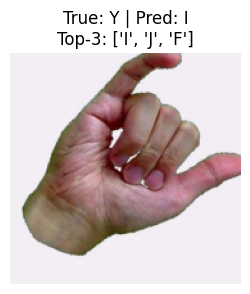

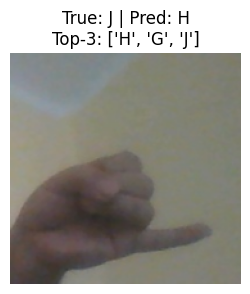

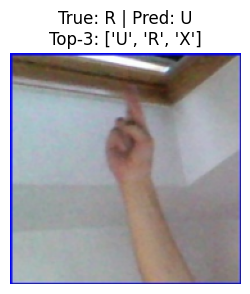

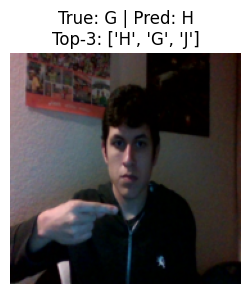

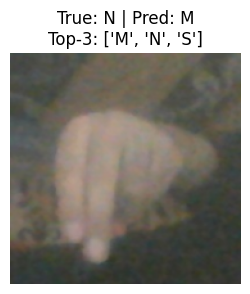

In [25]:
for img, true, pred, top3_idx, top3_probs in mistakes:
    plt.figure(figsize=(3, 3))
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.axis("off")
    plt.title(
        f"True: {classes[true]} | Pred: {classes[pred]}\n"
        f"Top-3: {[classes[i] for i in top3_idx]}"
    )
    plt.show()

In [26]:
arch_df = pd.DataFrame({
    "Feature": [
        "Input Size",
        "Conv Layers",
        "Channel Sizes",
        "Fully Connected Input",
        "Dropout",
        "Final Training Accuracy",
        "Final Validation Accuracy",
        "Test Accuracy"
    ],
    "Old Model": [
        "128×128",
        "3",
        "16 → 32 → 64",
        "64 × 14 × 14",
        "No",
        "96.70%",
        "98.51%",
        "98.40%"
    ],
    "New Model": [
        "180×180",
        "3",
        "32 → 64 → 128",
        "128 × 20 × 20",
        "Yes (0.5)",
        "89.57%",
        "97.72%",
        "97.34%"
    ]
})

arch_df

,Feature,Old Model,New Model
0,Input Size,128×128,180×180
1,Conv Layers,3,3
2,Channel Sizes,16 → 32 → 64,32 → 64 → 128
3,Fully Connected Input,64 × 14 × 14,128 × 20 × 20
4,Dropout,No,Yes (0.5)
5,Final Training Accuracy,96.70%,89.57%
6,Final Validation Accuracy,98.51%,97.72%
7,Test Accuracy,98.40%,97.34%


In [ ]:
# NOTE:
# The training and validation accuracy values below were recorded manually
# from the terminal output while running the training script (.py file).
# The model was trained outside of a Jupyter Notebook, so the results
# were not automatically stored and were instead copied into this table.
import pandas as pd

epochs = list(range(1, 17))

df = pd.DataFrame({
    "Epoch": epochs,

    "Old Train (%)": [
        36.31, 77.41, 86.55, 90.09, 91.92, 92.99, 93.86, 94.59,
        95.03, 95.42, 95.75, 96.02, 96.20, 96.42, 96.53, 96.70
    ],

    "Old Val (%)": [
        76.64, 89.92, 94.41, 95.23, 96.47, 97.21, 97.21, 97.56,
        97.81, 98.07, 98.36, 98.01, 98.64, 98.45, 98.71, 98.51
    ],

    "New Train (%)": [
        17.57, 48.06, 66.53, 73.91, 77.82, 80.55, 82.83, 84.01,
        85.26, 86.08, 87.00, 87.45, 88.38, 88.73, 89.32, 89.57
    ],

    "New Val (%)": [
        53.50, 80.56, 88.40, 90.65, 93.13, 94.09, 95.47, 95.36,
        96.18, 96.88, 96.65, 96.90, 97.17, 97.76, 97.66, 97.724
    ]
})

df

,Epoch,Old Train (%),Old Val (%),New Train (%),New Val (%)
0,1,36.31,76.64,17.57,53.500
1,2,77.41,89.92,48.06,80.560
2,3,86.55,94.41,66.53,88.400
3,4,90.09,95.23,73.91,90.650
4,5,91.92,96.47,77.82,93.130
5,6,92.99,97.21,80.55,94.090
6,7,93.86,97.21,82.83,95.470
7,8,94.59,97.56,84.01,95.360
8,9,95.03,97.81,85.26,96.180
9,10,95.42,98.07,86.08,96.880


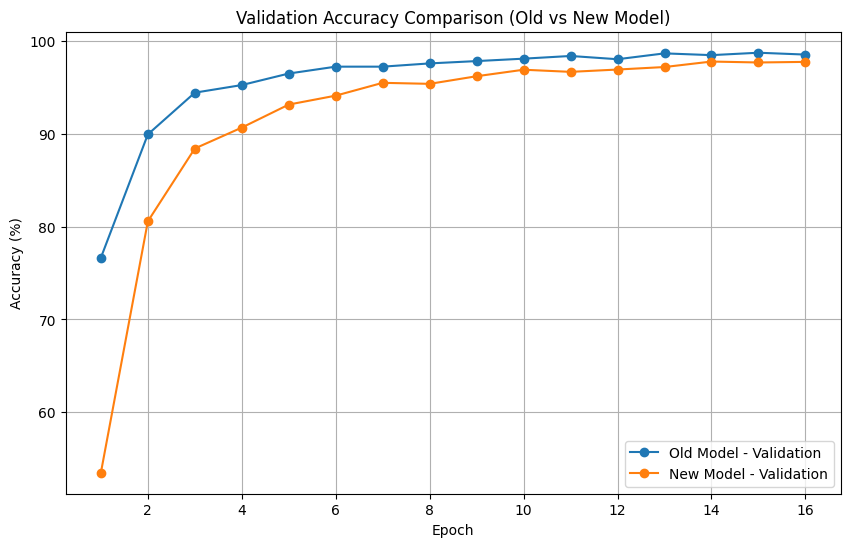

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(df["Epoch"], df["Old Val (%)"], marker="o", label="Old Model - Validation")
plt.plot(df["Epoch"], df["New Val (%)"], marker="o", label="New Model - Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy Comparison (Old vs New Model)")
plt.legend()
plt.grid(True)

plt.show()

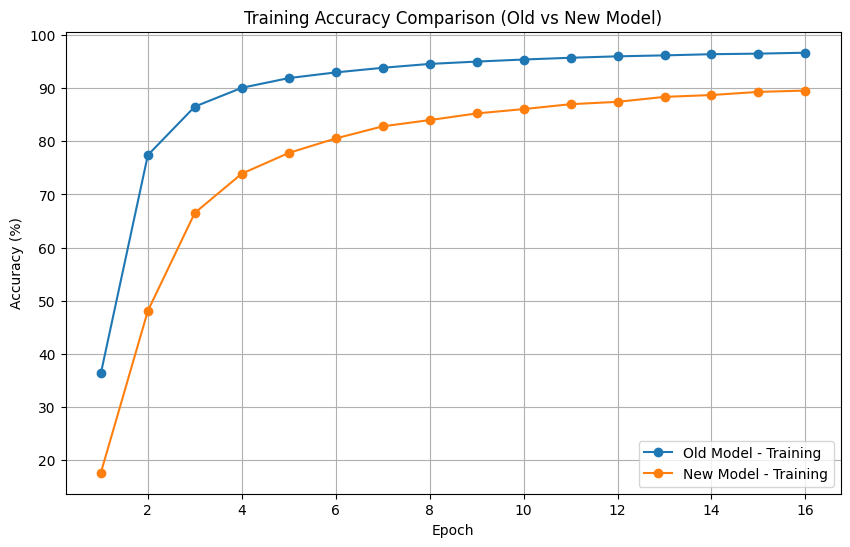

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(df["Epoch"], df["Old Train (%)"], marker="o", label="Old Model - Training")
plt.plot(df["Epoch"], df["New Train (%)"], marker="o", label="New Model - Training")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy Comparison (Old vs New Model)")
plt.legend()
plt.grid(True)

plt.show()

Model Comparison and Analysis

To improve performance, a second model was developed with a larger architecture. The new model used a higher input resolution (180×180 instead of 128×128), more convolutional channels, and included a dropout layer to reduce overfitting.

In terms of accuracy, the original model performed slightly better on the dataset, achieving higher validation accuracy (98.51% vs. 97.72%) and test accuracy (98.40% vs. 97.34%). This suggests that increasing model complexity did not directly improve performance on the training data. The new model also showed lower training accuracy (89.57% compared to 96.70%), which is likely due to its increased complexity and the use of dropout. With more parameters and regularization, the model learns more slowly and does not fit the training data as closely.

However, during real-time testing in the web application, the more complex model performed better in practice. When using the webcam, inputs often included unseen conditions such as different lighting, hand angles, and random backgrounds that were not perfectly represented in the dataset. Under these conditions, the newer model produced more stable and reliable predictions. The higher input resolution and increased feature capacity likely helped it capture more detailed visual information, making it more robust to these variations.

This comparison shows that while the simpler model achieved higher accuracy on the dataset, the more complex model generalized better to new and unpredictable inputs. Because the goal of the project was to create a usable real-time application, the more robust model was selected for deployment.